<center><font size="10"><b>FOOD DELIVERY TIME PREDICTION</b></font></center>

<center><font size="6"><b>AI FOUNDATIONS - MACHINE LEARNING</b></font></center>

<center><p float="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTpEngpfX8QSIARLuv3USMam8LPZQ-pmxuYtC9UwErEZQ&s=10" alt="DALL-E-2025-02-27-15-47-37-An-international-outdoor-DTH-store-labeled-AUTHORIZED-DTH-OUTLET-with-a-m"width=700></a>


## **PROBLEM STATEMENT**

Food delivery time can vary depending on factors such as distance, traffic, weather, vehicle condition, delivery person experience/rating, order type, and location. Accurately predicting delivery time can help food delivery services provide better estimated delivery times to customers and improve delivery planning.

## **OBJECTIVE**

The objective of this project is to develop a Machine Learning model that predicts the delivery time in minutes for a food order based on relevant order, delivery, traffic, weather, vehicle, and location-related features.

## **DATASET OVERVIEW**

- The dataset contains 41,953 rows and 20 columns.
- It contains information about food delivery orders and factors affecting delivery time.
- The dataset contains numerical, categorical, date, and time features.
- The target variable is Time_taken(min) represents the time taken to deliver the order in minutes.
- The target is currently stored as text, such as (min) 24, and will be converted into a numerical value.
- The dataset includes delivery, location, order, environmental, and vehicle-related features.

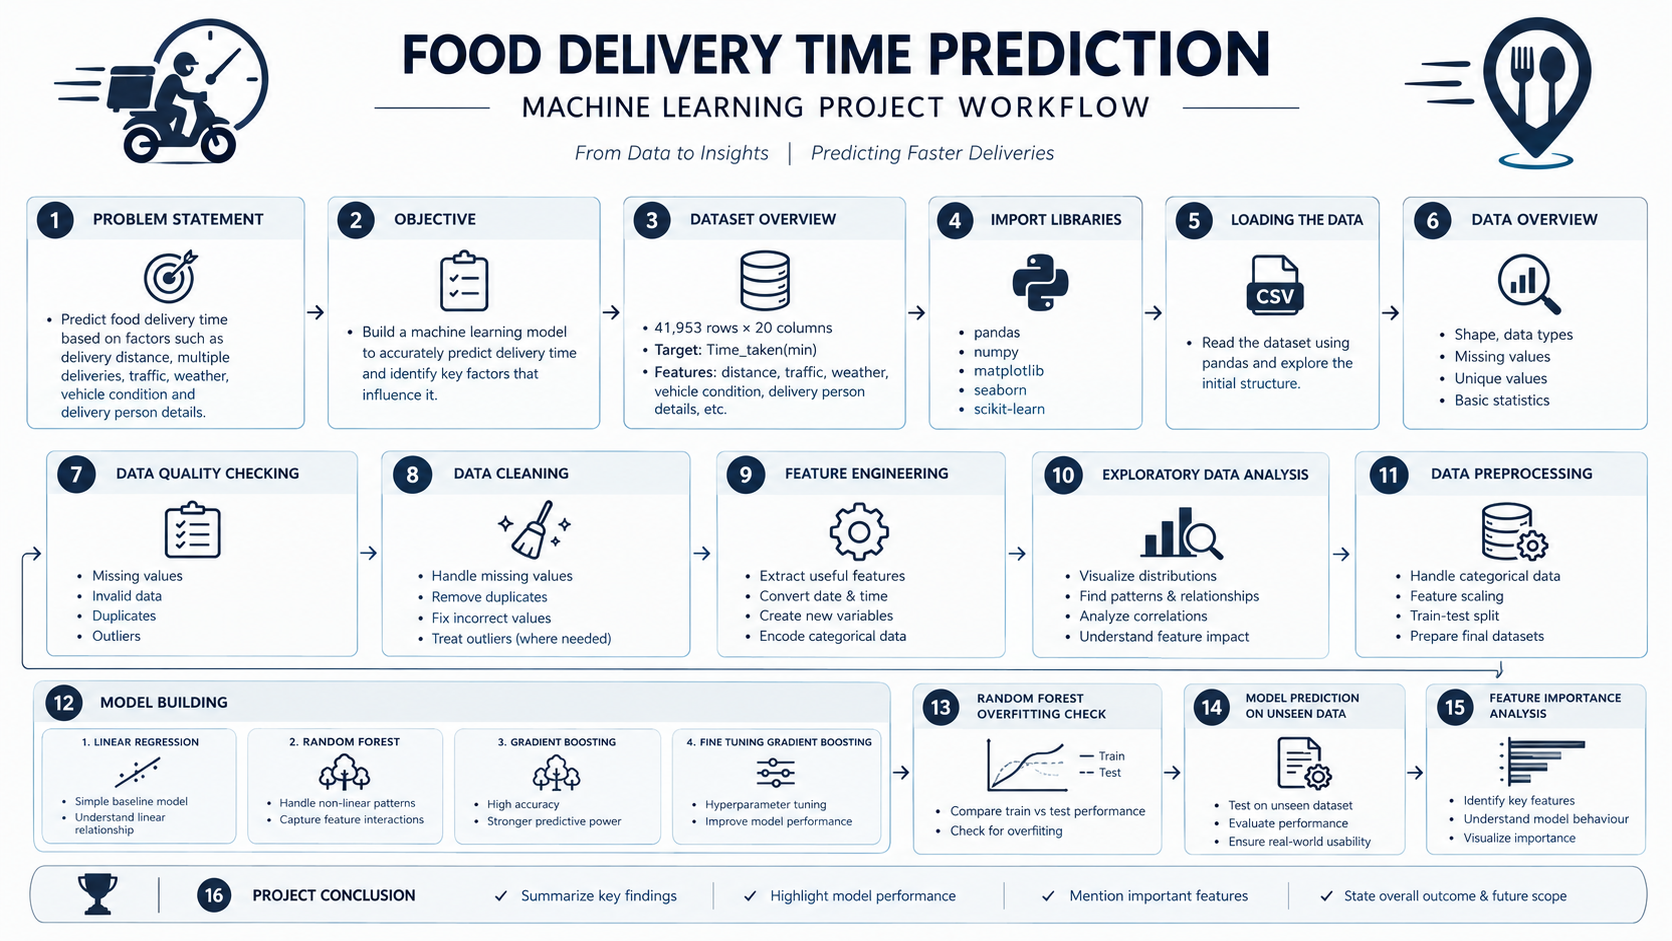

## **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
SEED = 42
np.random.seed(SEED)

## **LOADING THE DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json

with open("/content/drive/MyDrive/Self_project_GENAI/India-Food-Delivery-Time-Prediction.txt", "r") as file:
    data = json.load(file)

df = pd.DataFrame(data)

## **DATA OVERVIEW**

In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
df.shape

(41953, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          41953 non-null  object 
 3   Delivery_person_Ratings      41953 non-null  object 
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [ ]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1600


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
ID,object
Delivery_person_ID,object
Delivery_person_Age,object
Delivery_person_Ratings,object
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,object
Time_Orderd,object


## **DATA QUALITY CHECKING**

In [ ]:
# Invalid value check

df["Delivery_person_Ratings"].unique()

array(['4.9', '4.5', '4.4', '4.7', '4.6', '4.8', '4.2', '4.3', '4', '4.1',
       '5', 'NaN ', '3.8', '3.9', '3.7', '2.6', '3.5', '2.5', '3.6',
       '3.1', '2.7', '1', '3.3', '6', '3.4', '3.2', '2.8', '2.9', '3'],
      dtype=object)

- Delivery_person_Ratings contains mostly valid ratings between 1 and 5, but it also has a hidden missing value ('NaN ') and an invalid rating of 6. The column is stored as object datatype.

In [ ]:
# Check the number of unique values

df.nunique()

,0
ID,41953
Delivery_person_ID,1170
Delivery_person_Age,23
Delivery_person_Ratings,29
Restaurant_latitude,388
Restaurant_longitude,388
Delivery_location_latitude,4362
Delivery_location_longitude,4362
Order_Date,44
Time_Orderd,25569


- The dataset contains both high-unique-value features (IDs and time columns) and low-unique-value categorical features.
This confirms that the dataset contains a mix of identifiers, numerical, time, and categorical variables.

In [ ]:
# Check the outliers.

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Restaurant_latitude: 0 outliers
Restaurant_longitude: 3264 outliers
Delivery_location_latitude: 0 outliers
Delivery_location_longitude: 3264 outliers
Vehicle_condition: 0 outliers


- The IQR method identified outliers in longitude and delivery time, but these values may represent valid real-world locations and delivery durations. Therefore, they will not be removed automatically and will be investigated based on domain knowledge.

In [ ]:
print("Missing values:", df["Order_Date"].isnull().sum())
print("Unique values:", df["Order_Date"].nunique())

order_date = pd.to_datetime(df["Order_Date"], errors="coerce")

print("Invalid dates:", order_date.isnull().sum())
print("Date range:", order_date.min(), "to", order_date.max())

Missing values: 0
Unique values: 44
Invalid dates: 0
Date range: 2022-02-11 00:00:00 to 2022-04-06 00:00:00


/tmp/ipykernel_1797/3560611304.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  order_date = pd.to_datetime(df["Order_Date"], errors="coerce")


In [ ]:
print("Missing values:", df["Time_Orderd"].isnull().sum())
print("Unique values:", df["Time_Orderd"].nunique())

order_time = pd.to_datetime(
    df["Time_Orderd"], format="%H:%M", errors="coerce"
)

print("Invalid times:", order_time.isnull().sum())

Missing values: 1600
Unique values: 25569
Invalid times: 41953


In [ ]:
print("Missing values:", df["Time_Order_picked"].isnull().sum())
print("Unique values:", df["Time_Order_picked"].nunique())

picked_time = pd.to_datetime(
    df["Time_Order_picked"], format="%H:%M", errors="coerce"
)

print("Invalid times:", picked_time.isnull().sum())

Missing values: 0
Unique values: 26949
Invalid times: 41953


####**INFERENCE**

- Order_Date: No missing or invalid dates were found, with 44 unique dates in the given date range.
- Time_Orderd: Contains 1,600 missing values and requires further inspection because it has 25,569 unique values.
- Time_Order_picked: Contains no missing values but has 26,949 unique values, so its format and values require further inspection before cleaning.

## **DATA CLEANING**

In [ ]:
# Target Variable Analysis

df["Time_taken(min)"] = df["Time_taken(min)"].str.extract(r"(\d+)").astype(int)   # Convert Target variable text into numeric.

In [ ]:
df["Time_taken(min)"]

,Time_taken(min)
0,24
1,33
2,26
3,21
4,30
...,...
41948,33
41949,32
41950,16
41951,26


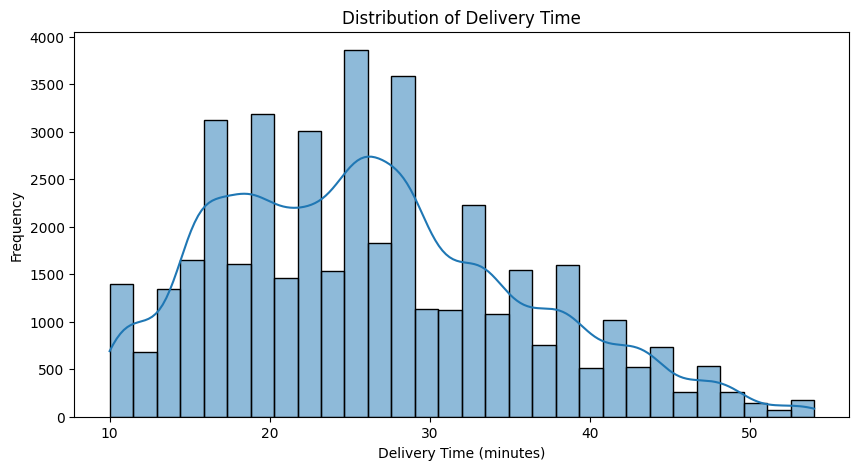

In [ ]:
# Check the distribution of delivery time.

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Time_taken(min)"],
    bins=30,
    kde=True)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df["Time_taken(min)"].describe()

,Time_taken(min)
count,41953.000000
mean,26.311539
std,9.380753
min,10.000000
25%,19.000000
50%,26.000000
75%,32.000000
max,54.000000


####**INFERENCE**

- The target variable is in the format of string (eg. (min) 24). So we converted it into the numeric.

- The average delivery time is about 26 minutes, with most deliveries taking 19–32 minutes. The variation is noticeable, with delivery times ranging from 10 to 54 minutes.

In [ ]:
# Numerical Feature Analysis

numeric_cols = df.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Vehicle_condition', 'Time_taken(min)'],
      dtype='object')


In [ ]:
df["Delivery_person_Age"] = pd.to_numeric(
    df["Delivery_person_Age"], errors="coerce"
)

df["Delivery_person_Ratings"] = pd.to_numeric(
    df["Delivery_person_Ratings"], errors="coerce"
)

df["multiple_deliveries"] = pd.to_numeric(
    df["multiple_deliveries"], errors="coerce"
)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Time_taken(min)'],
      dtype='object')


####**INFERENCE**

- Delivery_person_Age, Delivery_person_Ratings, multiple_deliveries also numeric values but it is in the object type so we converted it into the numeric type.


In [ ]:
# Date & Time Analysis.

print(df["Order_Date"].head(2))
print(df["Time_Orderd"].head(2))
print(df["Time_Order_picked"].head(2))

0    19-03-2022
1    25-03-2022
Name: Order_Date, dtype: object
0    11:33:33
1    19:45:37
Name: Time_Orderd, dtype: object
0    11:45:29
1    19:51:49
Name: Time_Order_picked, dtype: object


In [ ]:
# Convert Order_Date
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="%d-%m-%Y",
    errors="coerce"       # errors='coerce' converts invalid date or time values into NaT instead of stopping
)

# Convert Time_Orderd
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M:%S",
    errors="coerce"
)

# Convert Time_Order_picked
df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

####**INFERENCE**

- The date and time columns were stored in object format, so they were converted to proper datetime format for further analysis and processing.

In [ ]:
# Handle missing values in Time_Ordered.

# Keep missing Time_Ordered values as NaT
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Time_Orderd"].isna().sum()

np.int64(1600)

In [ ]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1719
Delivery_person_Ratings,1763
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1600


####**INFERENCE**

- Orderd contains 1,600 missing values, which are retained as NaT to preserve the missing information for later handling during preprocessing.

In [ ]:
# Handling Missing Values in Delivery_person_Age, Delivery_person_Ratings, multiple_deliveries.

df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median())

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median())

df["multiple_deliveries"] = df["multiple_deliveries"].fillna(
    df["multiple_deliveries"].median())

In [ ]:
df[[
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries"
]].isna().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
multiple_deliveries,0


####**INFERENCE**

- Missing values in Delivery_person_Age, Delivery_person_Ratings, and multiple_deliveries were imputed using the median. Median was chosen because it is less affected by extreme or unusual values and helps preserve the overall distribution of the features.

In [ ]:
# Handling the invalid values in the Rating.

df.loc[df["Delivery_person_Ratings"] > 5, "Delivery_person_Ratings"] = np.nan

In [ ]:
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median())

In [ ]:
df["Delivery_person_Ratings"].unique()

array([4.9, 4.5, 4.4, 4.7, 4.6, 4.8, 4.2, 4.3, 4. , 4.1, 5. , 3.8, 3.9,
       3.7, 2.6, 3.5, 2.5, 3.6, 3.1, 2.7, 1. , 3.3, 3.4, 3.2, 2.8, 2.9,
       3. ])

####**INFERENCE**

- The rating column has an expected range of 1–5, but contains an invalid value 6 and missing values, so they were replaced with NaN and handled using median imputation.

In [ ]:
# Handling Inconsistent Values in categorical columns

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


ID:
['0x4607 ' '0xb379 ' '0x5d6d ' ... '0x4f8d ' '0x5eee ' '0x5fb2 ']

Delivery_person_ID:
['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' ...
 'KOCRES04DEL01 ' 'BHPRES06DEL03 ' 'GOARES03DEL03 ']

Weatherconditions:
['conditions Sunny' 'conditions Stormy' 'conditions Sandstorms'
 'conditions Cloudy' 'conditions Fog' 'conditions Windy' 'conditions NaN']

Road_traffic_density:
['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']

Type_of_order:
['Snack ' 'Drinks ' 'Buffet ' 'Meal ']

Type_of_vehicle:
['motorcycle ' 'scooter ' 'electric_scooter ' 'bicycle ']

Festival:
['No ' 'Yes ' 'NaN ']

City:
['Urban ' 'Metropolitian ' 'NaN ' 'Semi-Urban ']


In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].str.strip()

In [ ]:
df = df.replace("NaN", np.nan)
df = df.replace("conditions NaN", np.nan)

In [ ]:
df.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1600


####**INFERENCE**

- Extra spaces and hidden missing values such as "NaN" and "conditions NaN" were identified and standardized. The hidden missing values were converted to actual NaN for proper handling.

In [ ]:
# Handling Missing Values in Categorical Features

categorical_missing = [
    "Weatherconditions",
    "Road_traffic_density",
    "Festival",
    "City"
]

for col in categorical_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1600


####**INFERENCE**

- The missing values were relatively low compared to the total dataset, so mode imputation was used for categorical features to retain all records while preserving the most common category.

In [ ]:
# Handling Inconsistent Pickup Delay Values

# Calculate pickup delay in minutes

df["Pickup_Delay"] = (df["Time_Order_picked"] - df["Time_Orderd"]).dt.total_seconds() / 60

# Handle orders picked up after midnight

midnight_crossing = (df["Pickup_Delay"] < 0) & (df["Time_Order_picked"].dt.hour < df["Time_Orderd"].dt.hour)

df.loc[midnight_crossing, "Pickup_Delay"] += 1440

# Replace remaining negative values with NaN

df.loc[df["Pickup_Delay"] < 0, "Pickup_Delay"] = np.nan

####**INFERENCE**

- Pickup delay was calculated in minutes, and negative delays caused by orders crossing midnight were corrected by adding 1,440 minutes. The remaining negative values, representing inconsistent time records, were converted to NaN to prevent invalid values from affecting the prediction model.

##**FEATURE ENGINEERING**

In [ ]:
# Feature Engineering 1: Order_Hour

# Extract the hour from Time_Orderd
df["Order_Hour"] = df["Time_Orderd"].dt.hour

In [ ]:
df[["Time_Orderd", "Order_Hour"]].head(3)

,Time_Orderd,Order_Hour
0,1900-01-01 11:33:33,11.0
1,1900-01-01 19:45:37,19.0
2,1900-01-01 08:32:58,8.0


####**INFERENCE**

- Order_Hour was extracted from Time_Orderd to represent the hour when the order was placed, helping the model identify time-of-day patterns.

In [ ]:
# Feature Engineering 2: Pickup_Hour

# Extract the hour from Time_Order_picked
df["Pickup_Hour"] = df["Time_Order_picked"].dt.hour

In [ ]:
df[["Time_Order_picked", "Pickup_Hour"]].head(3)

,Time_Order_picked,Pickup_Hour
0,1900-01-01 11:45:29,11
1,1900-01-01 19:51:49,19
2,1900-01-01 08:48:47,8


####**INFERENCE**

- Pickup_Hour was extracted from Time_Order_picked to represent the hour when the order was picked up, helping capture pickup timing patterns.

In [ ]:
# Feature Engineering 3: Pickup_Delay

# Calculate pickup delay and handle orders crossing midnight
df["Pickup_Delay"] = (
    (df["Time_Order_picked"] - df["Time_Orderd"])
    .dt.total_seconds() / 60
) % (24 * 60)

In [ ]:
df[["Time_Orderd", "Time_Order_picked", "Pickup_Delay"]].head()

,Time_Orderd,Time_Order_picked,Pickup_Delay
0,1900-01-01 11:33:33,1900-01-01 11:45:29,11.933333
1,1900-01-01 19:45:37,1900-01-01 19:51:49,6.200000
2,1900-01-01 08:32:58,1900-01-01 08:48:47,15.816667
3,1900-01-01 18:03:58,1900-01-01 18:12:52,8.900000
4,1900-01-01 13:34:16,1900-01-01 13:45:36,11.333333


####**INFERENCE**

- Pickup_Delay was calculated as the time difference between order placement and pickup, helping the model understand pickup waiting time.

In [ ]:
# Feature Engineering 4:Delivery Distance Calculation

# Calculate the distance between restaurant and delivery location

# Convert latitude and longitude from degrees to radians
lat1 = np.radians(df["Restaurant_latitude"])
lon1 = np.radians(df["Restaurant_longitude"])

lat2 = np.radians(df["Delivery_location_latitude"])
lon2 = np.radians(df["Delivery_location_longitude"])

# Haversine formula
dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
c = 2 * np.arcsin(np.sqrt(a))

# Earth's radius in kilometers
R = 6371

df["Delivery_Distance"] = R * c

In [ ]:
df[["Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Delivery_Distance"]].head()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Delivery_Distance
0,22.745049,75.892471,22.765049,75.912471,3.025149
1,12.913041,77.683237,13.043041,77.813237,20.183530
2,12.914264,77.678400,12.924264,77.688400,1.552758
3,11.003669,76.976494,11.053669,77.026494,7.790401
4,12.972793,80.249982,13.012793,80.289982,6.210138


####**INFERENCE**

- Haversine is a formula used to calculate the geographical distance between two locations using latitude and longitude.

- I Uses the latitude and longitude differences, calculates the angular distance between the two points, and then multiplies it by the Earth's radius to get the distance in kilometers.

- Delivery_Distance was created using the restaurant and customer latitude–longitude coordinates to represent the distance between them.

In [ ]:
# Feature Engineering 5: Day_of_Week

# Extract the day of the week from Order_Date.
df["Day_of_Week"] = df["Order_Date"].dt.dayofweek

####**INFERENCE**

- Day_of_Week was extracted from Order_Date to help identify differences in delivery time across different days of the week.

##**EXPLORATORY DATA ANALYSIS**


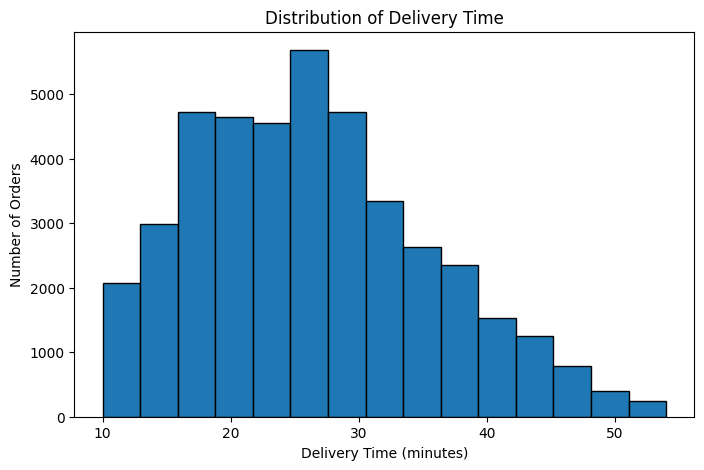

In [ ]:
# The distribution of delivery time.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Time_taken(min)"], bins=15, edgecolor="black")

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Time")

plt.show()

####**INFERENCE**

- The delivery time distribution is right-skewed, with most orders taking around 15–30 minutes. A smaller number of orders have higher delivery times, extending up to about 54 minutes.

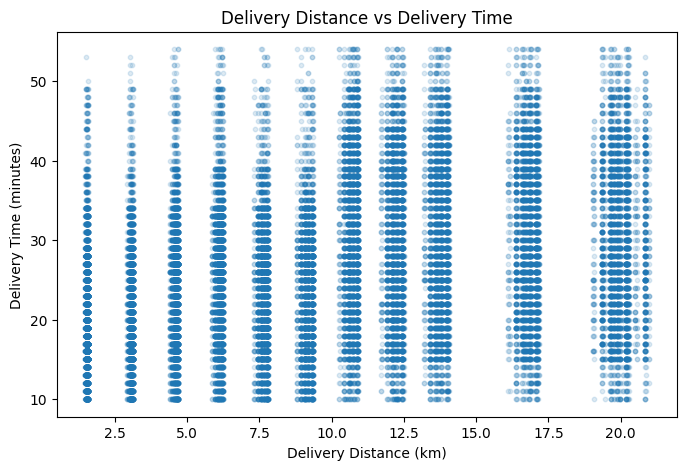

In [ ]:
# Delivery Distance vs Delivery Time

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Delivery_Distance"],
    df["Time_taken(min)"],
    alpha=0.15,
    s=10
)

plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.title("Delivery Distance vs Delivery Time")

plt.show()

####**INFERNCE**

- Delivery time varies across different delivery distances, with a slight tendency for longer distances to be associated with higher delivery times.

<Figure size 800x500 with 0 Axes>

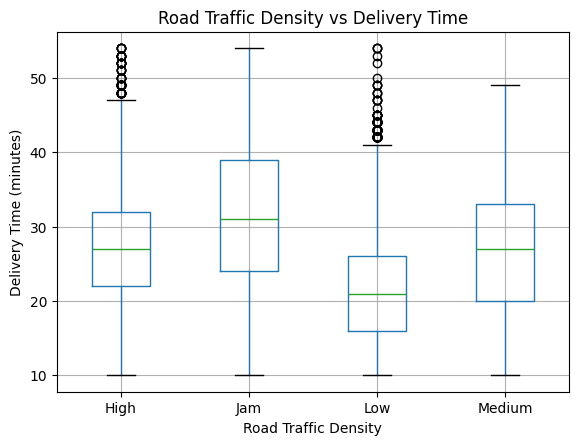

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Time_taken(min)",
    by="Road_traffic_density"
)

plt.xlabel("Road Traffic Density")
plt.ylabel("Delivery Time (minutes)")
plt.title("Road Traffic Density vs Delivery Time")
plt.suptitle("")

plt.show()

####**INFERENCE**

- Delivery time generally increases with higher road traffic density. Orders during jam conditions have the highest median delivery time, while low-traffic conditions have the lowest.

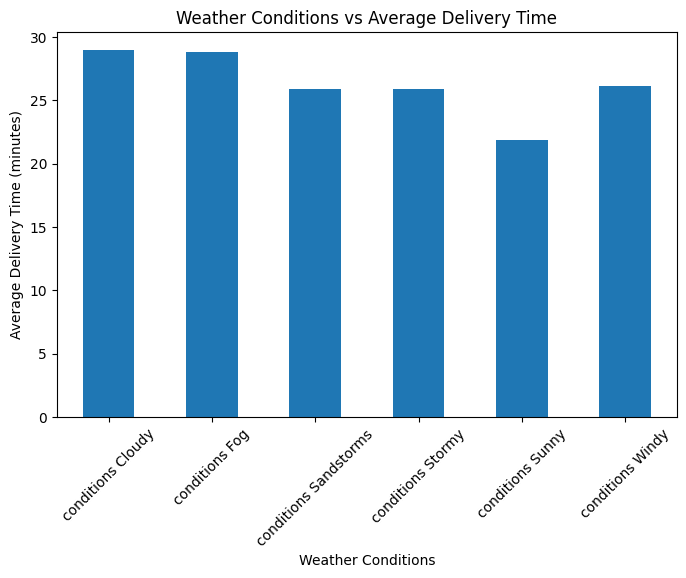

In [ ]:
# Weather Conditions vs Average Delivery Time

# Calculate average delivery time for each weather condition
avg_delivery_time = df.groupby("Weatherconditions")["Time_taken(min)"].mean()

# Plot bar chart
plt.figure(figsize=(8, 5))

avg_delivery_time.plot(kind="bar")

plt.xlabel("Weather Conditions")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Weather Conditions vs Average Delivery Time")
plt.xticks(rotation=45)

plt.show()

####**INFERENCE**

- Average delivery time varies across different weather conditions. Cloudy and foggy conditions have the highest average delivery times, while sunny conditions have the lowest, indicating that weather conditions can influence delivery time.

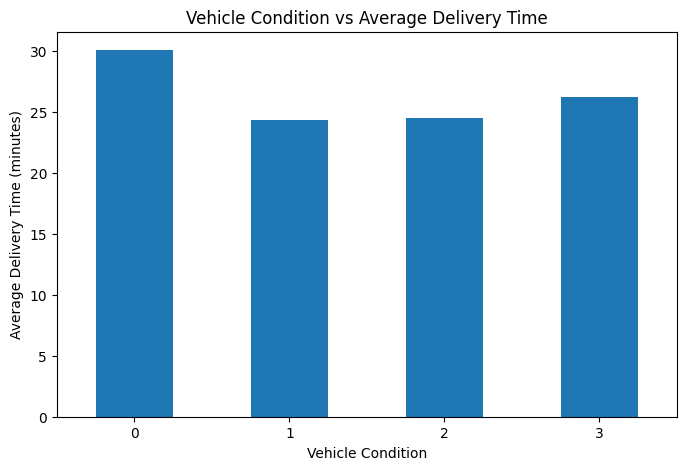

In [ ]:
# Vehicle Condition vs Delivery Time

# Calculate average delivery time for each vehicle condition
avg_delivery_time = df.groupby("Vehicle_condition")["Time_taken(min)"].mean()

# Plot bar chart
plt.figure(figsize=(8, 5))

avg_delivery_time.plot(kind="bar")

plt.xlabel("Vehicle Condition")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Vehicle Condition vs Average Delivery Time")
plt.xticks(rotation=0)

plt.show()

####**INFERENCE**

- Vehicle condition shows some variation in average delivery time. Condition 0 has the highest average delivery time, while Conditions 1 and 2 have lower average delivery times, indicating that vehicle condition may influence delivery time.

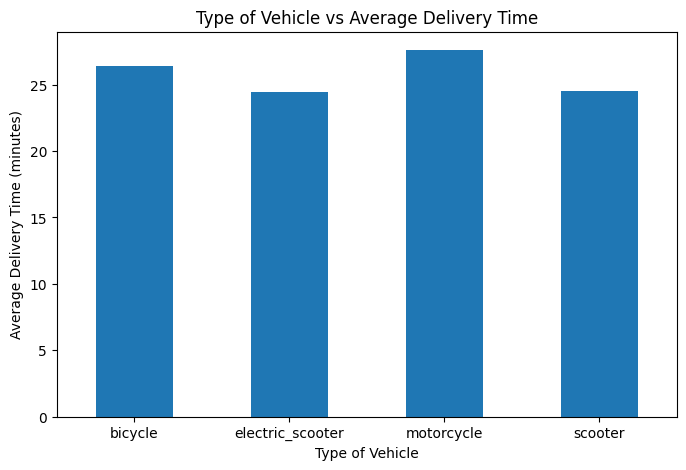

In [ ]:
# Type of Vehicle vs Delivery Time

# Calculate average delivery time for each vehicle type
avg_delivery_time = df.groupby("Type_of_vehicle")["Time_taken(min)"].mean()

# Plot bar chart
plt.figure(figsize=(8, 5))

avg_delivery_time.plot(kind="bar")

plt.xlabel("Type of Vehicle")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Type of Vehicle vs Average Delivery Time")
plt.xticks(rotation=0)

plt.show()

####**INFERENCE**

- Motorcycles have the highest average delivery time, while electric scooters and scooters have lower average delivery times, indicating that the type of vehicle may influence delivery time.

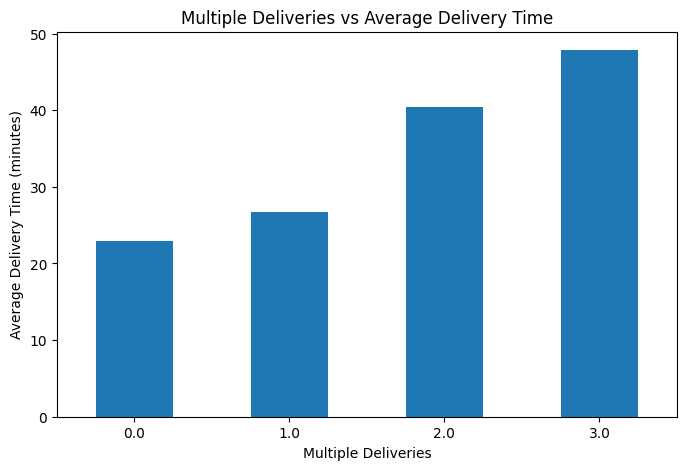

In [ ]:
# Multiple Deliveries vs Average Delivery Time

# Calculate average delivery time for each multiple delivery category
avg_delivery_time = df.groupby("multiple_deliveries")["Time_taken(min)"].mean()

# Plot bar chart
plt.figure(figsize=(8, 5))

avg_delivery_time.plot(kind="bar")

plt.xlabel("Multiple Deliveries")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Multiple Deliveries vs Average Delivery Time")
plt.xticks(rotation=0)

plt.show()

####**INFERENCE**

- Deliveries with 0 multiple orders have the lowest average delivery time, while those with 3 multiple orders have the highest, indicating that multiple deliveries can increase delivery time.

In [ ]:
# Correlation Analysis

numeric_cols = df.select_dtypes(include="number")

# Calculate correlation with delivery time
correlation = numeric_cols.corr()["Time_taken(min)"].sort_values(ascending=False)

print(correlation)

Time_taken(min)                1.000000
multiple_deliveries            0.377921
Delivery_Distance              0.320539
Delivery_person_Age            0.291947
Pickup_Hour                    0.203237
Order_Hour                     0.186558
Delivery_location_latitude     0.014335
Restaurant_latitude            0.012185
Delivery_location_longitude    0.010042
Restaurant_longitude           0.006680
Day_of_Week                    0.005317
Pickup_Delay                  -0.000224
Vehicle_condition             -0.235016
Delivery_person_Ratings       -0.334508
Name: Time_taken(min), dtype: float64


####**INFERENCE**

- The correlation analysis shows that multiple_deliveries (0.378) and Delivery_Distance (0.321) have relatively stronger positive relationships with delivery time, while Delivery_person_Ratings (-0.335) and Vehicle_condition (-0.235) show negative relationships. Features such as Pickup_Delay, Day_of_Week, and latitude/longitude have very weak linear relationships with delivery time.

##**DATA PREPROCESSING**



In [ ]:
# Input features
X = df[
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
        "Order_Hour",
        "Pickup_Hour",
        "Pickup_Delay",
        "Delivery_Distance",
        "Day_of_Week",
        "Vehicle_condition",
        "Road_traffic_density",
        "Weatherconditions",
        "Type_of_order",
        "Type_of_vehicle",
        "multiple_deliveries",
        "Festival",
        "City"
    ]
]

# Target variable
y = df["Time_taken(min)"]

In [ ]:
# check the missing value

X.isnull().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Hour,1600
Pickup_Hour,0
Pickup_Delay,1600
Delivery_Distance,0


In [ ]:
# Median imputation for Order_Hour

df["Order_Hour"] = df["Order_Hour"].fillna(
    df["Order_Hour"].median()
)

In [ ]:
# Median imputation for Pickup_Delay

df["Pickup_Delay"] = df["Pickup_Delay"].fillna(
    df["Pickup_Delay"].median()
)

In [ ]:
# Update the input feature after imputation

X = df[
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
        "Order_Hour",
        "Pickup_Hour",
        "Pickup_Delay",
        "Delivery_Distance",
        "Day_of_Week",
        "Vehicle_condition",
        "Road_traffic_density",
        "Weatherconditions",
        "Type_of_order",
        "Type_of_vehicle",
        "multiple_deliveries",
        "Festival",
        "City"
    ]
]

In [ ]:
# Again check the missing value

X.isnull().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Hour,0
Pickup_Hour,0
Pickup_Delay,0
Delivery_Distance,0


In [ ]:
# One-Hot Encoding of categorical features.

X = pd.get_dummies(
    X,
    columns=[
        "Road_traffic_density",
        "Weatherconditions",
        "Type_of_order",
        "Type_of_vehicle",
        "Festival",
        "City"
    ],
    drop_first=True
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (33562, 30)
X_test: (8391, 30)
y_train: (33562,)
y_test: (8391,)


####**INFERENCE**

- Missing values in Order_Hour and Pickup_Delay were handled using median imputation.
- Categorical features were converted into numerical values using One-Hot Encoding.
- Time_taken(min) was separated as the target variable, while the remaining selected columns were used as input features.
- The dataset was divided into 80% training data and 20% testing data.
- The training set contains 33,562 records, while the testing set contains 8,391 records.

##**MODEL BUILDING**



In [ ]:
model_results = pd.DataFrame(
    columns=["Model", "MAE", "RMSE", "R2"]
)

model_results

,Model,MAE,RMSE,R2


####**1. LINEAR REGRESSION**

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R²
r2 = r2_score(y_test, y_pred)

# Display results
model_results.loc[len(model_results)] = [
    "Linear Regression",
    mae,
    rmse,
    r2
]

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,4.769319,6.031104,0.57781


####**INFERENCE**

- MAE: The model's predictions differ from actual delivery times by approximately 4.77 minutes on average.
- RMSE: The RMSE of 6.03 minutes indicates the presence of some larger prediction errors.
- R²: The model achieved an R² of 0.57781, explaining approximately 57.8% of the variation in delivery time on the test data.
- These results provide a baseline that we can use to compare with our next models.

####**2. RANDOM FOREST**

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_y_pred = rf_model.predict(X_test)

In [ ]:
# Calculate MAE
rf_mae = mean_absolute_error(y_test, rf_y_pred)

# Calculate RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))

# Calculate R²
rf_r2 = r2_score(y_test, rf_y_pred)

# Store results
model_results.loc[len(model_results)] = [
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
]

# Display results
model_results

,Model,MAE,RMSE,R2
0,Linear Regression,4.769319,6.031104,0.577810
1,Random Forest,3.227425,4.085931,0.806226


####**INFERENCE**

- MAE: The Random Forest model's predictions differ from actual delivery times by approximately 3.23 minutes on average.
- RMSE: The RMSE of 4.09 minutes indicates that the model has relatively lower larger prediction errors.
- R²: The model achieved an R² of 0.80623, explaining approximately 80.6% of the variation in delivery time on the test data.
- These results show that the Random Forest model performs better than the Linear Regression baseline based on MAE, RMSE, and R².

####**3. Gradient Boosting**

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
gb_y_pred = gb_model.predict(X_test)

In [ ]:
# Gradient Boosting Model Evaluation

# Calculate MAE
gb_mae = mean_absolute_error(y_test, gb_y_pred)

# Calculate RMSE
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_y_pred))

# Calculate R²
gb_r2 = r2_score(y_test, gb_y_pred)

# Store results
model_results.loc[len(model_results)] = [
    "Gradient Boosting",
    gb_mae,
    gb_rmse,
    gb_r2
]

# Display results
model_results

,Model,MAE,RMSE,R2
0,Linear Regression,4.769319,6.031104,0.577810
1,Random Forest,3.227425,4.085931,0.806226
2,Gradient Boosting,3.668677,4.612102,0.753105


####**4. FINE TUNING GRADIENT BOOSTING**


In [ ]:
# Create the tuned Gradient Boosting model
gb_model_tuned = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model_tuned.fit(X_train, y_train)

# Make predictions
gb_y_pred_tuned = gb_model_tuned.predict(X_test)

In [ ]:
# Model Evaluation

gb_tuned_mae = mean_absolute_error(y_test, gb_y_pred_tuned)

gb_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, gb_y_pred_tuned)
)

gb_tuned_r2 = r2_score(y_test, gb_y_pred_tuned)

# Store results
model_results.loc[len(model_results)] = [
    "Gradient Boosting Tuned",
    gb_tuned_mae,
    gb_tuned_rmse,
    gb_tuned_r2
]

# Display results
model_results

,Model,MAE,RMSE,R2
0,Linear Regression,4.769319,6.031104,0.577810
1,Random Forest,3.227425,4.085931,0.806226
2,Gradient Boosting,3.668677,4.612102,0.753105
3,Gradient Boosting Tuned,3.657440,4.603149,0.754063


####**INFERENCE**

- MAE: The tuned Gradient Boosting model's predictions differ from actual delivery times by approximately 3.66 minutes on average.
- RMSE: The RMSE of 4.60 minutes indicates that some larger prediction errors are present.
- R²: The model achieved an R² of 0.7541, explaining approximately 75.4% of the variation in delivery time on the test data.
- Model Improvement: The tuned model showed a slight improvement compared with the original Gradient Boosting model.
- Comparison: Despite the improvement, Random Forest achieved better test-set performance based on MAE, RMSE, and R².

##**MODEL COMPARISON**

In [ ]:
model_results

,Model,MAE,RMSE,R2
0,Linear Regression,4.769319,6.031104,0.577810
1,Random Forest,3.227425,4.085931,0.806226
2,Gradient Boosting,3.668677,4.612102,0.753105
3,Gradient Boosting Tuned,3.657440,4.603149,0.754063


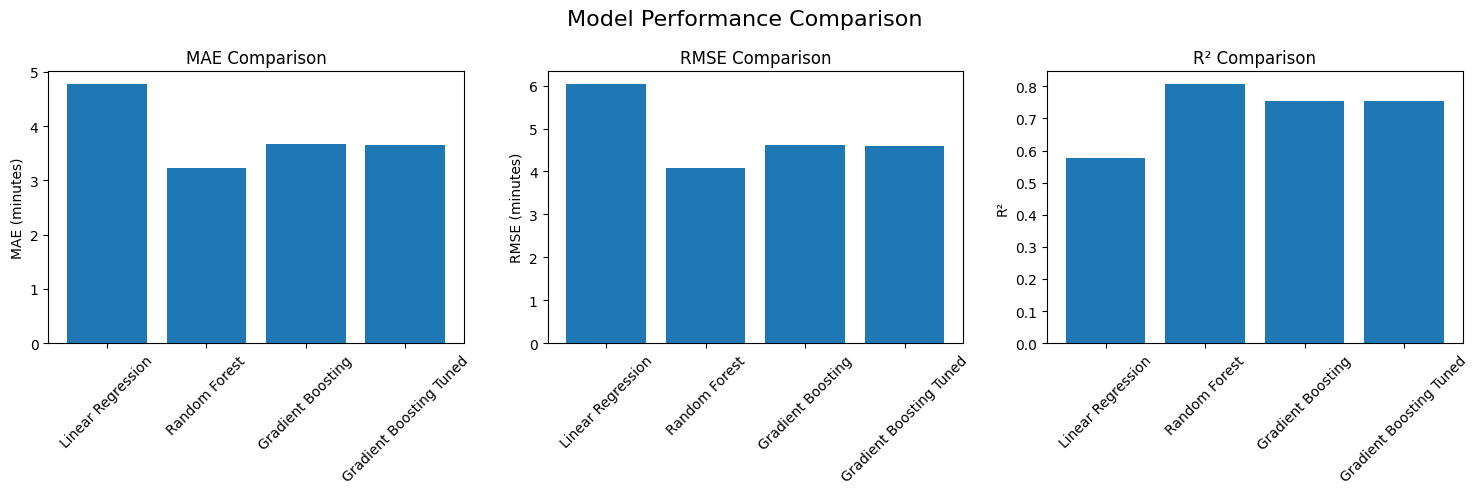

In [ ]:
import matplotlib.pyplot as plt

# Create one figure with 3 charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE
axes[0].bar(model_results["Model"], model_results["MAE"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE (minutes)")
axes[0].tick_params(axis="x", rotation=45)

# RMSE
axes[1].bar(model_results["Model"], model_results["RMSE"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE (minutes)")
axes[1].tick_params(axis="x", rotation=45)

# R²
axes[2].bar(model_results["Model"], model_results["R2"])
axes[2].set_title("R² Comparison")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=45)

# Overall title
fig.suptitle("Model Performance Comparison", fontsize=16)

plt.tight_layout()
plt.show()

####**INFERENCE**

- Random Forest achieved the lowest MAE and RMSE among the tested models.
- Random Forest also achieved the highest R² of 0.8062.
- Therefore, Random Forest was selected for the overfitting check and final unseen-data prediction.

##**RANDOM FOREST OVERFITTING CHECK**

In [ ]:
# Predictions on training data
rf_train_pred = rf_model.predict(X_train)

# Calculate training metrics
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_r2 = r2_score(y_train, rf_train_pred)

# Display Training Performance
print("Random Forest - Training Performance")
print("------------------------------------")
print("MAE :", rf_train_mae)
print("RMSE:", rf_train_rmse)
print("R²  :", rf_train_r2)

# Display Test Performance
print("\nRandom Forest - Test Performance")
print("--------------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest - Training Performance
------------------------------------
MAE : 1.201193611822895
RMSE: 1.528904019272949
R²  : 0.973573844175642

Random Forest - Test Performance
--------------------------------
MAE : 3.227424621618401
RMSE: 4.085931267469924
R²  : 0.8062257401330254


####**INFERENCE**

- Training: R² = 0.974 and MAE = 1.20 minutes.
- Testing: R² = 0.806 and MAE = 3.23 minutes.
- The difference shows some overfitting, but the model still performs well on unseen data.

##**MODEL PREDICTION ON UNSEEN DATA**

In [ ]:
sample_input = X_test.iloc[[1]]
actual_time = y_test.iloc[1]

# Make prediction
prediction = rf_model.predict(sample_input)
predicted_time = prediction[0]

# Calculate prediction error
error = abs(actual_time - predicted_time)

# Display results
print("Actual Delivery Time    :", f"{actual_time:.2f} minutes")
print("Predicted Delivery Time :", f"{predicted_time:.2f} minutes")
print("Prediction Error        :", f"{error:.2f} minutes")

Actual Delivery Time    : 18.00 minutes
Predicted Delivery Time : 15.24 minutes
Prediction Error        : 2.76 minutes


In [ ]:
sample_input = X_test.iloc[[5]]
actual_time = y_test.iloc[5]

# Make prediction
prediction = rf_model.predict(sample_input)
predicted_time = prediction[0]

# Calculate prediction error
error = abs(actual_time - predicted_time)

# Display results
print("Actual Delivery Time    :", f"{actual_time:.2f} minutes")
print("Predicted Delivery Time :", f"{predicted_time:.2f} minutes")
print("Prediction Error        :", f"{error:.2f} minutes")

Actual Delivery Time    : 20.00 minutes
Predicted Delivery Time : 23.18 minutes
Prediction Error        : 3.18 minutes


####**INFERENCE**

- 1st Unseen Order: Actual delivery time was 18 minutes, while the model predicted 15.24 minutes, with an error of 2.76 minutes.
- 2nd Unseen Order: Actual delivery time was 20 minutes, while the model predicted 23.18 minutes, with an error of 3.18 minutes.
- The model produced predictions close to the actual delivery times for these unseen orders.
- These examples demonstrate that the Random Forest model can make predictions on data it was not trained on.

##**FEATURE IMPORTANCE ANALYSIS**

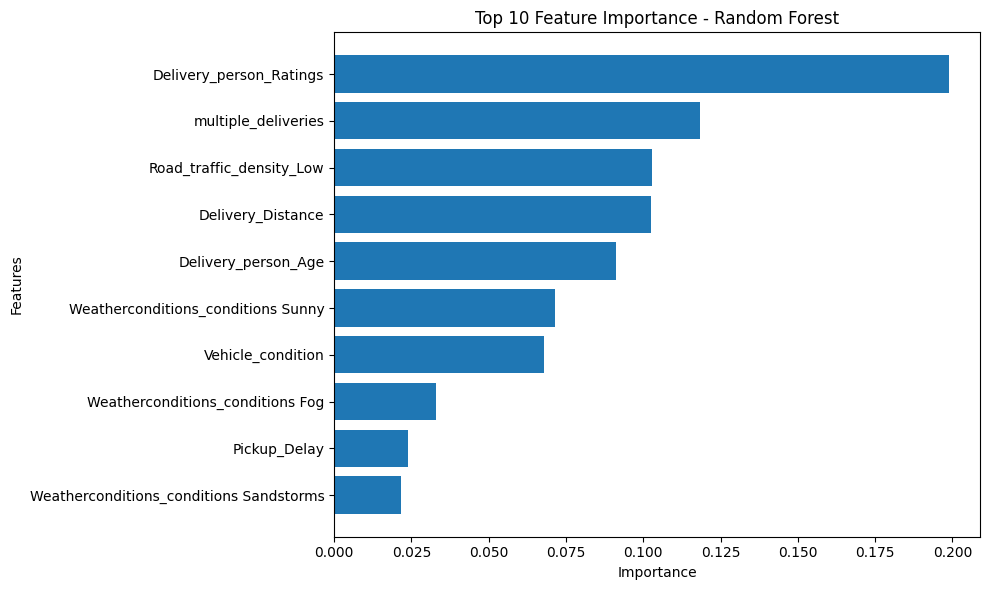

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_

# Get feature names
features = X_train.columns

# Get indices of top 10 features
top_indices = np.argsort(importance)[-10:]

# Create bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    features[top_indices],
    importance[top_indices]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

####**INFERENCE**

- Delivery_person_Ratings is the most important feature for predicting delivery time.
- Multiple_deliveries and Delivery_Distance are also highly important features.
- Overall, ratings, number of multiple deliveries, and delivery distance contribute strongly to the model's predictions.

##**PROJECT CONCLUSION**

- Objective: Developed a machine learning model to predict food delivery time using delivery distance, multiple deliveries, traffic, weather, vehicle condition, and delivery-person details.

- Model Development: Implemented Linear Regression as a baseline model, Random Forest to capture non-linear relationships and feature interactions, and Gradient Boosting for comparative evaluation.

- Model Evaluation: Compared the models using MAE, RMSE, and R² on the test dataset. Random Forest achieved the strongest performance, with MAE of 3.23 minutes, RMSE of 4.09 minutes, and R² of 0.8062.

- Feature Analysis: Random Forest feature importance identified Delivery_person_Ratings, multiple_deliveries, and Delivery_Distance as key contributors to delivery-time prediction.

- Final Testing: Validated the selected Random Forest model on unseen test data, demonstrating its ability to predict delivery times for orders not used during model training.